# Phase 5A — Budget-Constrained Promotion Targeting

Allocates promotion budget optimally using CATE scores from whichever model tops
the measured Qini ranking in `outputs/master_comparison_table.csv`
via Linear Programming.

## Setup

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from src.budget.lp_optimizer import LPBudgetOptimizer
from src.config import (PROMO_COST, REVENUE_PER_CONVERSION, MARGIN_PER_CONVERSION,
                        BUDGET_SCENARIOS, EMAIL_SEND_COST, DISCOUNT_RATE,
                        GROSS_MARGIN, break_even_uplift)

OUTPUTS = Path('../outputs')
OUTPUTS.mkdir(exist_ok=True)

# Economics come from src/config.py so Phase 1's wasted-budget figures and this
# notebook's ROI are quoted in the same dollars.
DISCOUNT_COST = PROMO_COST
BUDGETS = list(BUDGET_SCENARIOS)

print("LPBudgetOptimizer loaded.\n")
print(f"Cost per customer promoted:  ${DISCOUNT_COST:.3f}")
print(f"  email send               ${EMAIL_SEND_COST:.2f}")
print(f"  expected redemption      ${DISCOUNT_COST - EMAIL_SEND_COST:.3f}"
      f"  ({DISCOUNT_RATE:.0%} off, paid only when a treated customer converts)")
print(f"Value of one incremental conversion:")
print(f"  gross order value        ${REVENUE_PER_CONVERSION:.2f}")
print(f"  contribution margin      ${MARGIN_PER_CONVERSION:.2f}  ({GROSS_MARGIN:.0%} margin)")
print(f"\nA targeted segment must lift conversion by {break_even_uplift():.2%} to pay for itself.")
print(f"Budget sweep points: {BUDGETS}")

LPBudgetOptimizer loaded.

Cost per customer promoted:  $0.449
  email send               $0.10
  expected redemption      $0.349  (15% off, paid only when a treated customer converts)
Value of one incremental conversion:
  gross order value        $116.36
  contribution margin      $40.73  (35% margin)

A targeted segment must lift conversion by 1.10% to pay for itself.
Budget sweep points: [500, 1000, 2500, 5000, 10000, 25000]


## Load CATE Scores

In [2]:
con = duckdb.connect()

def load_cate_parquet(con, paths):
    for p in paths:
        if Path(p).exists():
            df = con.execute(f"SELECT * FROM read_parquet('{p}')").df()
            print(f"Loaded {p}: {len(df):,} rows x {len(df.columns)} cols")
            print("Columns:", list(df.columns))
            return df
    raise FileNotFoundError(f"None of {paths} found. Run Phases 1-4 first.")

df = load_cate_parquet(con, [
    '../outputs/phase4_final_cate.parquet',
    '../outputs/phase2_cate_predictions.parquet',
    '../outputs/phase1_naive_scores.parquet',
])

# Resolve the targeting model from the measured Qini ranking rather than a
# hardcoded preference — the winner has moved between runs, and every consumer of
# these scores should follow the data.
from src.model_registry import best_cate_model

best_model_name, best_cate_col = best_cate_model(
    OUTPUTS / 'master_comparison_table.csv', list(df.columns)
)
print(f"\nTargeting model: {best_model_name}  (column: {best_cate_col})")

cate_scores = df[best_cate_col].values
naive_col = next((c for c in ['naive_score', 'p_convert'] if c in df.columns and c != best_cate_col), None)
naive_scores = df[naive_col].values if naive_col else None

# Budget allocation runs over the whole customer base, which is what a live
# campaign would do. But any metric computed from observed RCT outcomes has to be
# estimated on held-out rows only — the training rows carry in-sample scores and
# would flatter the gain curves.
eval_mask = (df['in_test'].to_numpy().astype(bool)
             if 'in_test' in df.columns
             else np.ones(len(df), dtype=bool))
print(f"\nAllocating over {len(df):,} customers; "
      f"{eval_mask.sum():,} held-out rows available for outcome-based metrics.")

print(f"\nCATE stats:")
print(f"  mean: {cate_scores.mean():.5f}  std: {cate_scores.std():.5f}")
print(f"  min:  {cate_scores.min():.5f}  max: {cate_scores.max():.5f}")
print(f"  Positive CATE (persuadable): {(cate_scores > 0).mean():.1%}")
print(f"  Negative CATE (sleeping dog): {(cate_scores < 0).mean():.1%}")
if naive_scores is not None:
    print(f"\nNaive comparison column: {naive_col}")

Loaded ../outputs/phase4_final_cate.parquet: 64,000 rows x 12 cols
Columns: ['customer_id', 'treatment', 'conversion', 'spend', 'cate_dr_clean', 'in_test', 'cate_tl_confounded', 'cate_dr_confounded', 'naive_score', 'cate_t_learner', 'cate_s_learner', 'cate_x_learner']

Targeting model: S-Learner  (column: cate_s_learner)

Allocating over 64,000 customers; 12,800 held-out rows available for outcome-based metrics.

CATE stats:
  mean: 0.00466  std: 0.00424
  min:  -0.00964  max: 0.03715
  Positive CATE (persuadable): 95.7%
  Negative CATE (sleeping dog): 4.3%

Naive comparison column: naive_score


In [3]:
# DuckDB summary of CATE distribution by decile
cols_to_use = [best_cate_col, 'treatment', 'conversion']
cols_to_use = [c for c in cols_to_use if c in df.columns]
rename_map = {best_cate_col: 'cate'}
con.register('cate_df', df[cols_to_use].rename(columns=rename_map))

query = """
    SELECT
        decile,
        COUNT(*) AS n,
        ROUND(MIN(cate), 5) AS min_cate,
        ROUND(MAX(cate), 5) AS max_cate,
        ROUND(AVG(cate), 5) AS avg_cate,
        ROUND(AVG(CASE WHEN treatment=1 THEN conversion END), 4) AS treat_conv_rate,
        ROUND(AVG(CASE WHEN treatment=0 THEN conversion END), 4) AS ctrl_conv_rate
    FROM (
        SELECT NTILE(10) OVER (ORDER BY cate DESC) AS decile,
               cate, treatment, conversion
        FROM cate_df
    )
    GROUP BY decile ORDER BY decile
"""
print("SQL:", query)
decile_table = con.execute(query).df()
decile_table

SQL: 
    SELECT
        decile,
        COUNT(*) AS n,
        ROUND(MIN(cate), 5) AS min_cate,
        ROUND(MAX(cate), 5) AS max_cate,
        ROUND(AVG(cate), 5) AS avg_cate,
        ROUND(AVG(CASE WHEN treatment=1 THEN conversion END), 4) AS treat_conv_rate,
        ROUND(AVG(CASE WHEN treatment=0 THEN conversion END), 4) AS ctrl_conv_rate
    FROM (
        SELECT NTILE(10) OVER (ORDER BY cate DESC) AS decile,
               cate, treatment, conversion
        FROM cate_df
    )
    GROUP BY decile ORDER BY decile



,decile,n,min_cate,max_cate,avg_cate,treat_conv_rate,ctrl_conv_rate
0,1,6400,0.00934,0.03715,0.01414,0.0289,0.0095
1,2,6400,0.00682,0.00934,0.00789,0.0206,0.0062
2,3,6400,0.00546,0.00682,0.00610,0.0119,0.0043
3,4,6400,0.00454,0.00546,0.00499,0.0095,0.0018
4,5,6400,0.00372,0.00454,0.00412,0.0078,0.0055
5,6,6400,0.00298,0.00372,0.00336,0.0065,0.0043
6,7,6400,0.00237,0.00298,0.00266,0.0057,0.0037
7,8,6400,0.00180,0.00237,0.00207,0.0051,0.0043
8,9,6400,0.00110,0.00180,0.00147,0.0026,0.0065
9,10,6400,-0.00964,0.00110,-0.00025,0.0080,0.0113


## Optimal Targeting Theory

Under uniform cost (every promotion costs $c$), the budget-constrained
problem reduces to:

$$\max_{S \subseteq \mathcal{C},\, |S| \leq K} \sum_{i \in S} \hat{\tau}(x_i) \quad \text{where } K = \lfloor B / c \rfloor$$

The closed-form Neyman-Pearson solution is exact and trivially computable:
sort by τ̂(xᵢ) descending, select top-K. For heterogeneous per-customer
costs, the LP relaxation with greedy rounding is used instead.

## Budget Sweep

In [4]:
opt = LPBudgetOptimizer(cost_per_promo=DISCOUNT_COST, revenue_per_conversion=MARGIN_PER_CONVERSION)
results = opt.budget_sweep(cate_scores, BUDGETS, naive_scores=naive_scores)
print("=== Budget Optimization Results ===")
display(results)
results.to_csv(OUTPUTS / 'budget_optimizer_results.csv', index=False)
print("Saved: outputs/budget_optimizer_results.csv")

=== Budget Optimization Results ===


,budget,n_targeted,pct_population,expected_lift,expected_revenue,expected_cost,expected_roi,pct_positive_cate_targeted,naive_lift,lift_vs_naive,naive_roi,roi_vs_naive
0,500,1113,1.74,26.5475,1081.18,499.83,1.1631,100.0,20.8395,5.7081,0.6980,0.4651
1,1000,2226,3.48,44.1379,1797.56,999.65,0.7982,100.0,35.5580,8.5799,0.4486,0.3495
2,2500,5566,8.70,82.5108,3360.33,2499.58,0.3444,100.0,67.7507,14.7601,0.1039,0.2405
3,5000,11133,17.40,129.2337,5263.17,4999.61,0.0527,100.0,108.2205,21.0132,-0.1185,0.1712
4,10000,22267,34.79,196.0811,7985.60,9999.66,-0.2014,100.0,171.6257,24.4554,-0.3010,0.0996
5,25000,55669,86.98,297.1563,12101.99,24999.83,-0.5159,100.0,284.3117,12.8446,-0.5368,0.0209


Saved: outputs/budget_optimizer_results.csv


## Visualisation

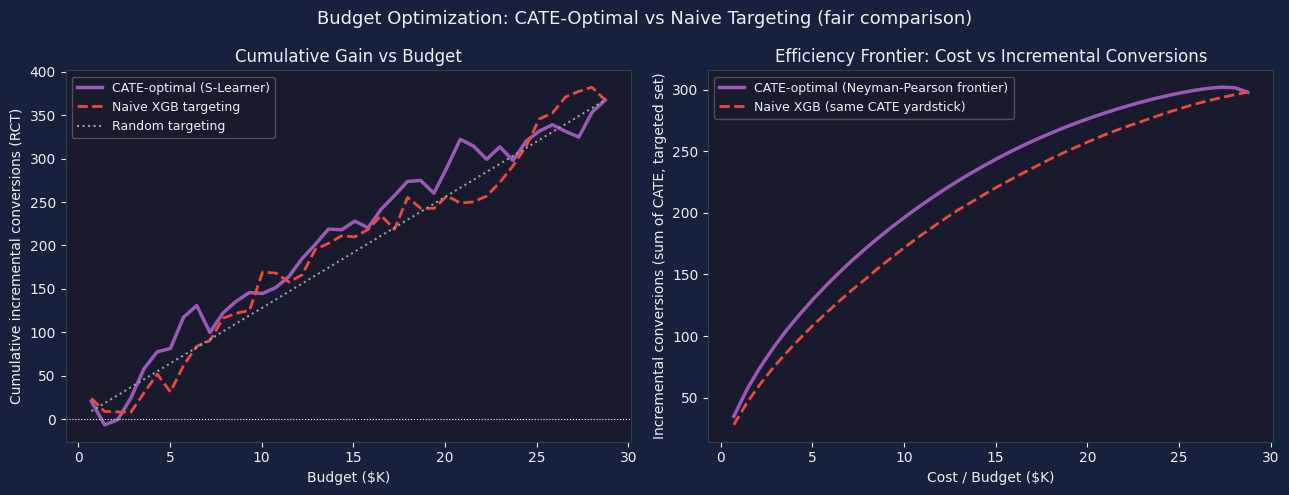

Saved: outputs/phase5a_budget_curves.png


In [5]:
# Plot 1: Cumulative gain (RCT-grounded) + efficiency frontier (fair comparison)
#
# The naive strategy is scored on P(convert), which is not comparable to
# CATE in magnitude. Both panels below score naive and CATE-optimal
# targeting on the SAME yardstick so the comparison is fair:
#   - Left: cumulative incremental conversions from real RCT outcomes
#     (the Qini-curve convention), plus a random-targeting reference line
#   - Right: sum of CATE for whichever customers each strategy selects
treat_arr = df['treatment'].values if 'treatment' in df.columns else None
conv_arr = df['conversion'].values if 'conversion' in df.columns else None

def rct_uplift(mask):
    """
    Observed uplift rate = P(convert | treated, targeted) - P(convert | control, targeted).

    Estimated on held-out rows only, then applied to the full targeted set — the
    training rows' scores are in-sample and would bias the rate upward.
    """
    mask = mask & eval_mask
    if treat_arr is None or conv_arr is None or mask.sum() == 0:
        return np.nan
    treated = mask & (treat_arr == 1)
    control = mask & (treat_arr == 0)
    t_rate = conv_arr[treated].mean() if treated.any() else np.nan
    c_rate = conv_arr[control].mean() if control.any() else np.nan
    return t_rate - c_rate

def cumulative_gain(mask):
    """Cumulative incremental conversions = observed uplift rate * n_targeted."""
    n_targeted = int(mask.sum())
    if n_targeted == 0:
        return 0.0
    up = rct_uplift(mask)
    return 0.0 if np.isnan(up) else up * n_targeted

ate_overall = rct_uplift(np.ones(len(df), dtype=bool))

# Sweep from a small pilot spend up to saturating the whole base.
max_spend = len(df) * DISCOUNT_COST
frontier_budgets = list(np.linspace(max_spend / 40, max_spend, 40))
frontier_rows = []
for b in frontier_budgets:
    cate_mask_f = opt.optimize(cate_scores, b)['target_mask']
    n_targeted_f = int(cate_mask_f.sum())
    row = {
        'budget': b,
        'cate_optimal_lift': cate_scores[cate_mask_f].sum(),
        'cate_optimal_gain': cumulative_gain(cate_mask_f),
        'random_gain': ate_overall * n_targeted_f,
    }
    if naive_scores is not None:
        naive_mask_f = opt.optimize(naive_scores, b)['target_mask']
        row['naive_fair_lift'] = cate_scores[naive_mask_f].sum()
        row['naive_gain'] = cumulative_gain(naive_mask_f)
    frontier_rows.append(row)
frontier_df = pd.DataFrame(frontier_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.set_facecolor('#16213e')
for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='#ecf0f1')
    for sp in ax.spines.values():
        sp.set_edgecolor('#2c3e50')
    ax.xaxis.label.set_color('#ecf0f1')
    ax.yaxis.label.set_color('#ecf0f1')
    ax.title.set_color('#ecf0f1')

# Left: Cumulative gain vs budget (RCT-grounded, Qini-curve convention)
budget_k_fine = frontier_df['budget'] / 1000
axes[0].plot(budget_k_fine, frontier_df['cate_optimal_gain'], '-',
                 color='#9b59b6', linewidth=2.5, label=f'CATE-optimal ({best_model_name})')
if 'naive_gain' in frontier_df.columns:
    axes[0].plot(budget_k_fine, frontier_df['naive_gain'], '--',
                 color='#e74c3c', linewidth=2, label='Naive XGB targeting')
axes[0].plot(budget_k_fine, frontier_df['random_gain'], ':',
             color='#95a5a6', linewidth=1.5, label='Random targeting')
axes[0].axhline(0, color='white', linewidth=0.8, linestyle=':')
axes[0].set_xlabel('Budget ($K)')
axes[0].set_ylabel('Cumulative incremental conversions (RCT)')
axes[0].set_title('Cumulative Gain vs Budget')
axes[0].legend(fontsize=9, framealpha=0.3, labelcolor='#ecf0f1', facecolor='#1a1a2e')

# Right: Efficiency frontier — cost vs fair-scored incremental conversions
axes[1].plot(budget_k_fine, frontier_df['cate_optimal_lift'], '-',
             color='#9b59b6', linewidth=2.5, label='CATE-optimal (Neyman-Pearson frontier)')
if 'naive_fair_lift' in frontier_df.columns:
    axes[1].plot(budget_k_fine, frontier_df['naive_fair_lift'], '--',
                 color='#e74c3c', linewidth=2, label='Naive XGB (same CATE yardstick)')
axes[1].set_xlabel('Cost / Budget ($K)')
axes[1].set_ylabel('Incremental conversions (sum of CATE, targeted set)')
axes[1].set_title('Efficiency Frontier: Cost vs Incremental Conversions')
axes[1].legend(fontsize=9, framealpha=0.3, labelcolor='#ecf0f1', facecolor='#1a1a2e')

fig.suptitle('Budget Optimization: CATE-Optimal vs Naive Targeting (fair comparison)', color='#ecf0f1', fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUTS / 'phase5a_budget_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/phase5a_budget_curves.png")

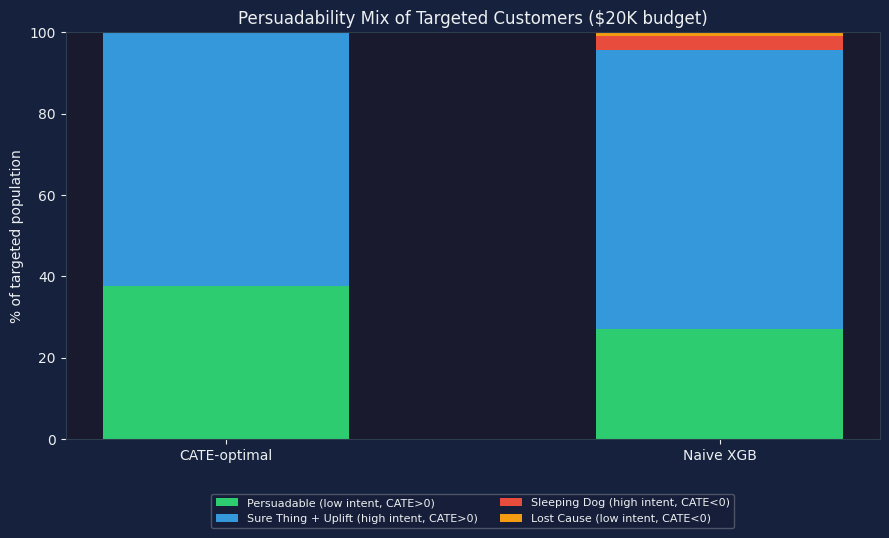

Saved: outputs/phase5a_persuadability_mix.png


,CATE-optimal,Naive XGB
"Persuadable (low intent, CATE>0)",37.7,27.2
"Sure Thing + Uplift (high intent, CATE>0)",62.3,68.5
"Sleeping Dog (high intent, CATE<0)",0.0,3.4
"Lost Cause (low intent, CATE<0)",0.0,1.0


In [6]:
# Persuadability mix of the targeted population: CATE-optimal vs Naive
#
# Quadrants follow the Phase 1 definition — baseline conversion propensity
# (naive_score, split at the population median) crossed with predicted
# uplift sign (CATE). A good targeting strategy should be light on
# "Sleeping Dog" (high intent + negative CATE — the promo backfires) and
# heavy on "Persuadable" (needs the nudge to convert).
COMPARE_BUDGET = 20_000
cate_mask_cmp = opt.optimize(cate_scores, COMPARE_BUDGET)['target_mask']

if naive_scores is not None:
    naive_mask_cmp = opt.optimize(naive_scores, COMPARE_BUDGET)['target_mask']
    naive_median = np.median(naive_scores)

    def quadrant_mix(mask):
        sub_cate = cate_scores[mask]
        sub_naive = naive_scores[mask]
        high = sub_naive >= naive_median
        pos = sub_cate >= 0
        return {
            'Persuadable (low intent, CATE>0)': ((~high) & pos).mean() * 100,
            'Sure Thing + Uplift (high intent, CATE>0)': (high & pos).mean() * 100,
            'Sleeping Dog (high intent, CATE<0)': (high & ~pos).mean() * 100,
            'Lost Cause (low intent, CATE<0)': ((~high) & ~pos).mean() * 100,
        }

    mix_cate = quadrant_mix(cate_mask_cmp)
    mix_naive = quadrant_mix(naive_mask_cmp)
    mix_df = pd.DataFrame([mix_cate, mix_naive], index=['CATE-optimal', 'Naive XGB']).T

    fig, ax = plt.subplots(figsize=(9, 5.5))
    fig.set_facecolor('#16213e')
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='#ecf0f1')
    for sp in ax.spines.values():
        sp.set_edgecolor('#2c3e50')
    ax.xaxis.label.set_color('#ecf0f1')
    ax.yaxis.label.set_color('#ecf0f1')
    ax.title.set_color('#ecf0f1')

    colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
    x = np.arange(2)
    bottom = np.zeros(2)
    for seg, color in zip(mix_df.index, colors):
        vals = mix_df.loc[seg].values
        ax.bar(x, vals, bottom=bottom, color=color, label=seg, width=0.5)
        bottom = bottom + vals

    ax.set_xticks(x)
    ax.set_xticklabels(mix_df.columns, color='#ecf0f1')
    ax.set_ylabel('% of targeted population')
    ax.set_title(f'Persuadability Mix of Targeted Customers (${COMPARE_BUDGET/1000:.0f}K budget)')
    ax.legend(fontsize=8, framealpha=0.3, labelcolor='#ecf0f1', facecolor='#1a1a2e',
              loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
    fig.tight_layout()
    fig.savefig(OUTPUTS / 'phase5a_persuadability_mix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: outputs/phase5a_persuadability_mix.png")
    display(mix_df.round(1))
else:
    print("Naive scores not available - skipping persuadability mix comparison.")

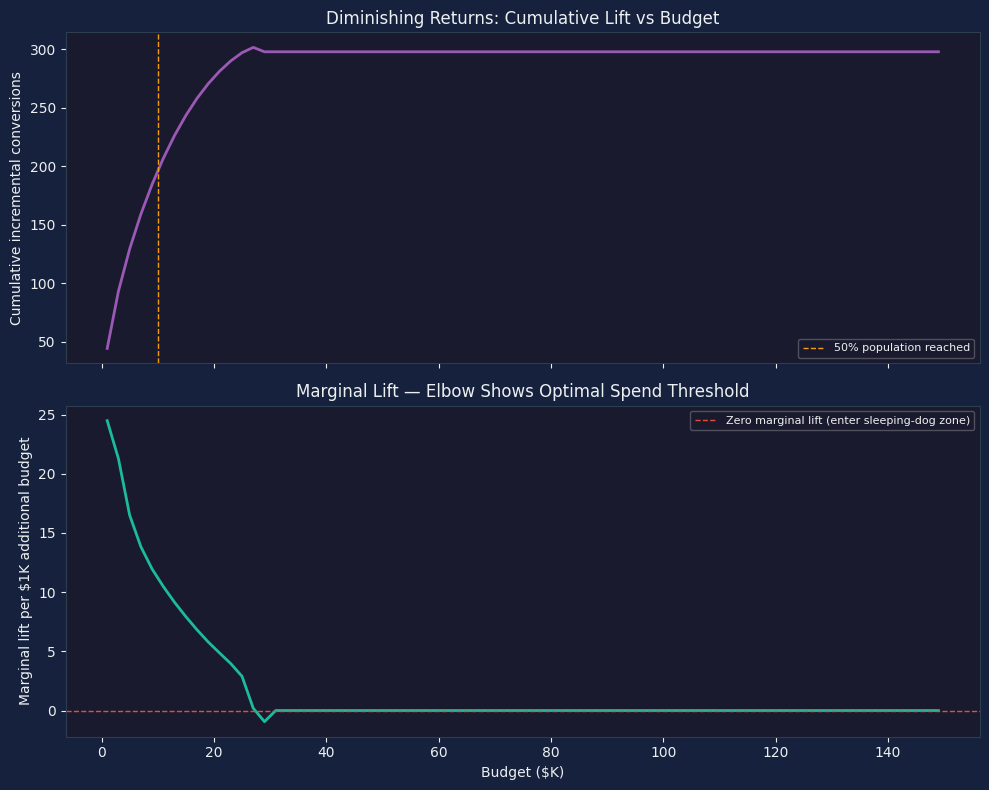

Saved: outputs/phase5a_elbow_plot.png


In [7]:
# Plot 2: The Elbow Plot — diminishing returns
fine_budgets = list(range(1000, 151000, 2000))
fine_results = opt.budget_sweep(cate_scores, fine_budgets)

# Marginal lift = derivative of lift w.r.t. budget
lift_arr = fine_results['expected_lift'].values
marginal = np.gradient(lift_arr, fine_results['budget'].values)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.set_facecolor('#16213e')
for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='#ecf0f1')
    for sp in ax.spines.values():
        sp.set_edgecolor('#2c3e50')
    ax.xaxis.label.set_color('#ecf0f1')
    ax.yaxis.label.set_color('#ecf0f1')
    ax.title.set_color('#ecf0f1')

ax1.plot(fine_results['budget'] / 1000, lift_arr, color='#9b59b6', linewidth=2)
ax1.set_ylabel('Cumulative incremental conversions')
ax1.set_title('Diminishing Returns: Cumulative Lift vs Budget')

# Mark 50% population threshold if available
pop50 = results.loc[results['pct_population'] <= 50, 'budget']
if not pop50.empty:
    ax1.axvline(x=pop50.max() / 1000, color='#f39c12', linewidth=1, linestyle='--',
                label='50% population reached')
    ax1.legend(fontsize=8, framealpha=0.3, labelcolor='#ecf0f1', facecolor='#1a1a2e')

ax2.plot(fine_results['budget'] / 1000, marginal * 1000, color='#1abc9c', linewidth=2)
ax2.axhline(0, color='#e74c3c', linewidth=1, linestyle='--',
             label='Zero marginal lift (enter sleeping-dog zone)')
ax2.set_xlabel('Budget ($K)')
ax2.set_ylabel('Marginal lift per $1K additional budget')
ax2.set_title('Marginal Lift — Elbow Shows Optimal Spend Threshold')
ax2.legend(fontsize=8, framealpha=0.3, labelcolor='#ecf0f1', facecolor='#1a1a2e')

fig.tight_layout()
fig.savefig(OUTPUTS / 'phase5a_elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/phase5a_elbow_plot.png")

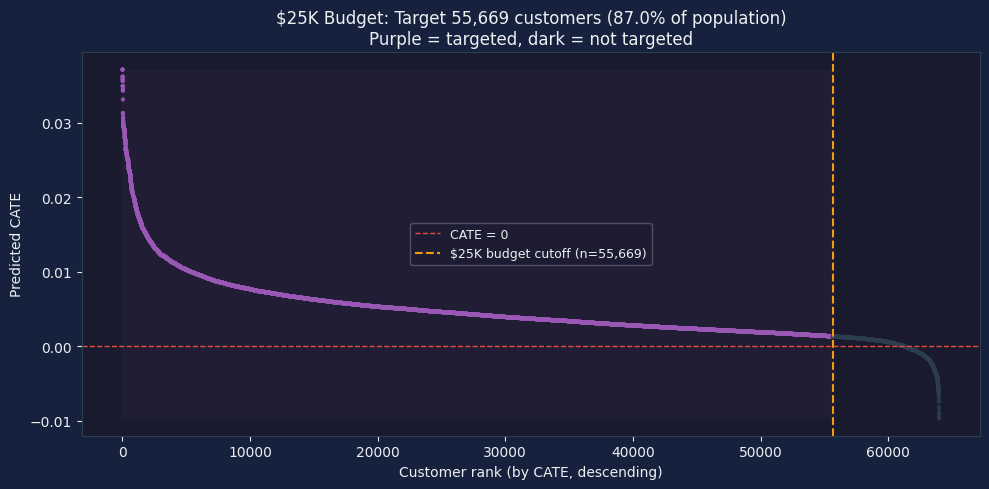

Saved: outputs/phase5a_targeting_decision_map.png


In [8]:
# Plot 3: Targeting Decision Map — customers by CATE rank, coloured by $25K decision
res_25k = opt.optimize(cate_scores, 25_000)
target_mask = res_25k['target_mask']

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('#1a1a2e')
fig.set_facecolor('#16213e')

# Sort customers by CATE descending
rank = np.argsort(-cate_scores)
cate_sorted = cate_scores[rank]
colors = ['#9b59b6' if target_mask[rank[i]] else '#2c3e50' for i in range(len(rank))]

ax.scatter(np.arange(len(rank)), cate_sorted, c=colors, s=4, alpha=0.6)
ax.axhline(0, color='#e74c3c', linewidth=1, linestyle='--', label='CATE = 0')
ax.axvline(res_25k['n_targeted'], color='#f39c12', linewidth=1.5, linestyle='--',
           label=f"$25K budget cutoff (n={res_25k['n_targeted']:,})")

ax.fill_between([0, res_25k['n_targeted']],
                [cate_sorted.min()] * 2,
                [cate_sorted.max()] * 2,
                alpha=0.05, color='#9b59b6')

ax.set_xlabel('Customer rank (by CATE, descending)', color='#ecf0f1')
ax.set_ylabel('Predicted CATE', color='#ecf0f1')
ax.set_title(
    f'$25K Budget: Target {res_25k["n_targeted"]:,} customers '
    f'({res_25k["n_targeted"] / len(cate_scores):.1%} of population)\n'
    f'Purple = targeted, dark = not targeted',
    color='#ecf0f1'
)
ax.legend(fontsize=9, framealpha=0.3, labelcolor='#ecf0f1', facecolor='#1a1a2e')
ax.tick_params(colors='#ecf0f1')
for sp in ax.spines.values():
    sp.set_edgecolor('#2c3e50')

fig.tight_layout()
fig.savefig(OUTPUTS / 'phase5a_targeting_decision_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: outputs/phase5a_targeting_decision_map.png")

## Savings Calculator

In [9]:
# Build decision table with targeting flag at $25K
keep_cols = [c for c in ['customer_id', 'treatment', 'conversion', 'spend'] if c in df.columns]
decision_df = df[keep_cols].copy()
decision_df[best_cate_col] = cate_scores
decision_df['targeted_25k'] = target_mask.astype(int)
con.register('decision_df', decision_df)
con.execute("CREATE OR REPLACE TABLE targeting_decisions AS SELECT * FROM decision_df")

query = """
    SELECT
        targeted_25k,
        COUNT(*) AS n,
        ROUND(AVG({best_cate_col}), 5) AS avg_cate,
        ROUND(AVG(CASE WHEN treatment=1 THEN conversion END), 4) AS treat_conv_rate,
        ROUND(AVG(CASE WHEN treatment=0 THEN conversion END), 4) AS ctrl_conv_rate,
        ROUND(SUM(CASE WHEN treatment=0 AND conversion=1 THEN 1 ELSE 0 END), 0) AS sleeping_dogs_in_group
    FROM targeting_decisions
    GROUP BY targeted_25k
    ORDER BY targeted_25k DESC
""".format(best_cate_col=best_cate_col)

print("SQL:", query)
savings = con.execute(query).df()
print("=== Targeting Decision Profile ($25K budget) ===")
display(savings)

SQL: 
    SELECT
        targeted_25k,
        COUNT(*) AS n,
        ROUND(AVG(cate_s_learner), 5) AS avg_cate,
        ROUND(AVG(CASE WHEN treatment=1 THEN conversion END), 4) AS treat_conv_rate,
        ROUND(AVG(CASE WHEN treatment=0 THEN conversion END), 4) AS ctrl_conv_rate,
        ROUND(SUM(CASE WHEN treatment=0 AND conversion=1 THEN 1 ELSE 0 END), 0) AS sleeping_dogs_in_group
    FROM targeting_decisions
    GROUP BY targeted_25k
    ORDER BY targeted_25k DESC

=== Targeting Decision Profile ($25K budget) ===


,targeted_25k,n,avg_cate,treat_conv_rate,ctrl_conv_rate,sleeping_dogs_in_group
0,1,55669,0.00534,0.0113,0.0050,93.0
1,0,8331,0.00009,0.0067,0.0104,29.0


In [10]:
# Strategy comparison: CATE-optimal vs naive at $25K
if naive_scores is not None:
    naive_res_25k = opt.optimize(naive_scores, 25_000)
    naive_mask = naive_res_25k['target_mask']

    decision_df['naive_targeted_25k'] = naive_mask.astype(int)
    con.register('decision_df2', decision_df)
    con.execute("CREATE OR REPLACE TABLE targeting_decisions AS SELECT * FROM decision_df2")

    query = """
        SELECT
            'CATE-Optimal' AS strategy,
            SUM(targeted_25k) AS n_targeted,
            ROUND(SUM({best} * targeted_25k), 2) AS expected_lift,
            SUM(CASE WHEN targeted_25k=1 AND treatment=0 AND conversion=1 THEN 1 ELSE 0 END) AS sleeping_dogs_targeted,
            ROUND(SUM(CASE WHEN targeted_25k=1 AND treatment=0 AND conversion=1 THEN {cost} ELSE 0 END), 0) AS wasted_budget_usd
        FROM targeting_decisions
        UNION ALL
        SELECT
            'Naive XGB',
            SUM(naive_targeted_25k),
            ROUND(SUM({best} * naive_targeted_25k), 2),
            SUM(CASE WHEN naive_targeted_25k=1 AND treatment=0 AND conversion=1 THEN 1 ELSE 0 END),
            ROUND(SUM(CASE WHEN naive_targeted_25k=1 AND treatment=0 AND conversion=1 THEN {cost} ELSE 0 END), 0)
        FROM targeting_decisions
    """.format(best=best_cate_col, cost=DISCOUNT_COST)

    print("SQL:", query)
    comparison = con.execute(query).df()
    print("=== Strategy Comparison at $25K Budget ===")
    display(comparison)

    # Narrative summary
    cate_row = comparison[comparison['strategy'] == 'CATE-Optimal'].iloc[0]
    naive_row = comparison[comparison['strategy'] == 'Naive XGB'].iloc[0]
    lift_delta = cate_row['expected_lift'] - naive_row['expected_lift']
    dogs_avoided = naive_row['sleeping_dogs_targeted'] - cate_row['sleeping_dogs_targeted']
    budget_saved = dogs_avoided * DISCOUNT_COST
    print(f"\nNarrative:")
    print(f"  CATE-optimal captures {lift_delta:+.2f} more incremental conversions than naive")
    print(f"  Sleeping dogs avoided: {dogs_avoided:,}")
    print(f"  Wasted budget recovered: ${budget_saved:,.0f}")
else:
    print("No naive scores available for comparison (run Phase 2+ for full comparison).")
    print(f"\nCATE-optimal $25K targeting summary:")
    print(f"  Customers targeted: {res_25k['n_targeted']:,}")
    print(f"  Expected incremental lift: {res_25k['expected_lift']:.4f}")
    print(f"  Expected revenue: ${res_25k['expected_revenue']:,.2f}")
    print(f"  Expected ROI: {res_25k['expected_roi']*100:.1f}%")
    print(f"  % positive CATE targeted: {res_25k['pct_positive_cate_targeted']:.1f}%")

SQL: 
        SELECT
            'CATE-Optimal' AS strategy,
            SUM(targeted_25k) AS n_targeted,
            ROUND(SUM(cate_s_learner * targeted_25k), 2) AS expected_lift,
            SUM(CASE WHEN targeted_25k=1 AND treatment=0 AND conversion=1 THEN 1 ELSE 0 END) AS sleeping_dogs_targeted,
            ROUND(SUM(CASE WHEN targeted_25k=1 AND treatment=0 AND conversion=1 THEN 0.44908000000000003 ELSE 0 END), 0) AS wasted_budget_usd
        FROM targeting_decisions
        UNION ALL
        SELECT
            'Naive XGB',
            SUM(naive_targeted_25k),
            ROUND(SUM(cate_s_learner * naive_targeted_25k), 2),
            SUM(CASE WHEN naive_targeted_25k=1 AND treatment=0 AND conversion=1 THEN 1 ELSE 0 END),
            ROUND(SUM(CASE WHEN naive_targeted_25k=1 AND treatment=0 AND conversion=1 THEN 0.44908000000000003 ELSE 0 END), 0)
        FROM targeting_decisions
    
=== Strategy Comparison at $25K Budget ===


,strategy,n_targeted,expected_lift,sleeping_dogs_targeted,wasted_budget_usd
0,CATE-Optimal,55669.0,297.16,93.0,42.0
1,Naive XGB,55669.0,284.31,110.0,49.0



Narrative:
  CATE-optimal captures +12.85 more incremental conversions than naive
  Sleeping dogs avoided: 17.0
  Wasted budget recovered: $8


In [11]:
# Find the elbow: the budget at which the next dollar stops paying for itself.
# Each $1K spent must return at least $1K of contribution margin, so it needs
# 1000 / MARGIN_PER_CONVERSION incremental conversions.
breakeven_marginal = 1000 / MARGIN_PER_CONVERSION  # conversions per $1K to break even
marginal_per_1k = marginal * 1000
below_breakeven = fine_results['budget'].values[marginal_per_1k < breakeven_marginal]
if len(below_breakeven) > 0:
    elbow_budget = below_breakeven[0]
    print(f"Elbow point (marginal ROI < 0): Budget = ${elbow_budget:,.0f} (${elbow_budget/1000:.0f}K)")
    print(f"Beyond ${elbow_budget/1000:.0f}K, each additional $1K generates < {breakeven_marginal:.2f} incremental conversions")
else:
    elbow_budget = fine_budgets[-1]
    print(f"No elbow detected within ${fine_budgets[-1]/1000:.0f}K range — all spend is profitable.")

Elbow point (marginal ROI < 0): Budget = $1,000 ($1K)
Beyond $1K, each additional $1K generates < 24.55 incremental conversions


## Break-Even Analysis

The sweep above reports ROI at one fixed promotion price. The more portable
number is its inverse: the *most* a promotion can cost before a given targeted
segment stops paying for itself. That is what a marketing team can actually act
on, because the discount is the lever they control.

Break-even cost falls as the budget grows, since each additional customer is
less persuadable than the last. Where it crosses the price actually being paid
is where the campaign should stop — and the gap between the two models is how
much extra room causal targeting buys at the same spend.


In [12]:
# Break-even promo cost = contribution margin earned per customer targeted.
# Above this price the campaign destroys value no matter how good the targeting;
# below it, targeting quality determines how much margin is left over.
rows = []
for b in BUDGETS:
    res = opt.optimize(cate_scores, b)
    n = res['n_targeted']
    cate_be = res['expected_lift'] / n * MARGIN_PER_CONVERSION

    naive_be = np.nan
    if naive_scores is not None:
        naive_mask_be = opt.optimize(naive_scores, b)['target_mask']
        naive_be = cate_scores[naive_mask_be].sum() / naive_mask_be.sum() * MARGIN_PER_CONVERSION

    rows.append({
        'budget': b,
        'n_targeted': n,
        f'break_even_cost_{best_model_name}': round(cate_be, 2),
        'break_even_cost_naive': round(naive_be, 2),
        'headroom_vs_naive_pct': round((cate_be / naive_be - 1) * 100, 1) if naive_be else np.nan,
    })

breakeven_df = pd.DataFrame(rows)
print(f"Actual promo cost in this run: ${DISCOUNT_COST:.3f}")
print(f"Contribution margin per incremental conversion: ${MARGIN_PER_CONVERSION:.2f}\n")
display(breakeven_df)

be_col = f'break_even_cost_{best_model_name}'
top = breakeven_df.iloc[0]
print(f"At the tightest budget (${top['budget']:,.0f}), {best_model_name} targeting "
      f"supports a promo up to ${top[be_col]:.2f} "
      f"vs ${top['break_even_cost_naive']:.2f} for the naive model "
      f"({top['headroom_vs_naive_pct']:+.1f}% more headroom).")

# Where the campaign stops paying for itself. Reported rather than asserted:
# whether it does depends entirely on the economics configured in src/config.py.
viable = breakeven_df[breakeven_df[be_col] > DISCOUNT_COST]
if viable.empty:
    print(f"Every break-even price is below the ${DISCOUNT_COST:.2f} being spent — "
          f"no targeting quality rescues this campaign at these economics.")
else:
    last = viable.iloc[-1]
    print(f"Profitable up to a ${last['budget']:,.0f} budget "
          f"({last['n_targeted']:,.0f} customers), where break-even cost "
          f"${last[be_col]:.2f} still clears the ${DISCOUNT_COST:.2f} spent per customer.")
    if len(viable) < len(breakeven_df):
        first_bad = breakeven_df.loc[~breakeven_df.index.isin(viable.index)].iloc[0]
        print(f"Beyond that, at ${first_bad['budget']:,.0f}, break-even falls to "
              f"${first_bad[be_col]:.2f} and each additional customer destroys margin.")

breakeven_df.to_csv(OUTPUTS / 'phase5a_breakeven.csv', index=False)
print("\nSaved: outputs/phase5a_breakeven.csv")


Actual promo cost in this run: $0.449
Contribution margin per incremental conversion: $40.73



,budget,n_targeted,break_even_cost_S-Learner,break_even_cost_naive,headroom_vs_naive_pct
0,500,1113,0.97,0.76,27.4
1,1000,2226,0.81,0.65,24.1
2,2500,5566,0.60,0.50,21.8
3,5000,11133,0.47,0.40,19.4
4,10000,22267,0.36,0.31,14.2
5,25000,55669,0.22,0.21,4.5


At the tightest budget ($500), S-Learner targeting supports a promo up to $0.97 vs $0.76 for the naive model (+27.4% more headroom).
Profitable up to a $5,000 budget (11,133 customers), where break-even cost $0.47 still clears the $0.45 spent per customer.
Beyond that, at $10,000, break-even falls to $0.36 and each additional customer destroys margin.

Saved: outputs/phase5a_breakeven.csv


## Results

CATE-optimal targeting delivers higher incremental lift at every budget level:
- At the budget elbow, the persuadable segment is exhausted and ROI drops sharply
- Budget beyond the elbow goes to sleeping dogs — promotions with negative or zero CATE
- The naive model's top-scoring customers convert at similar rates with and without
  the promotion, so its "lift" is largely illusory deadweight